In [8]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

path = "../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"

In [5]:
rna_hl_human = np.load( path + 'rna_hl_human.npz')

# See what arrays are stored in the file
print(rna_hl_human.files)

print("\nArray shapes:")
print(f"X shape: {rna_hl_human['X'].shape}")
print(f"y shape: {rna_hl_human['y'].shape}")
print(f"genes shape: {rna_hl_human['genes'].shape}")

print(f"\nX dimensions: {rna_hl_human['X'].ndim}")
if rna_hl_human['X'].ndim == 3:
    print(f"X first sample shape: {rna_hl_human['X'][0].shape}")
    print(f"X first sample, first feature vector: {rna_hl_human['X'][0, 0, :5]}")  # First 5 features
elif rna_hl_human['X'].ndim == 2:
    print(f"X first sample (first 10 features): {rna_hl_human['X'][0, :10]}")


['X', 'y', 'genes']

Array shapes:
X shape: (12968, 12288, 6)
y shape: (12968,)
genes shape: (12968,)

X dimensions: 3
X first sample shape: (12288, 6)
X first sample, first feature vector: [0. 1. 0. 0. 0.]


In [6]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [10]:
# Flatten X: (num_genes, 12288, 6) -> (num_genes, 12288*6)
X_flat = rna_hl_human['X'].reshape(rna_hl_human['X'].shape[0], -1)

# Run PCA
n_components = 128  # or any number you want
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_flat)

# Create DataFrame with genes as index and PCA embeddings as columns
genes = rna_hl_human['genes']
column_names = [f'PCA_{i}' for i in range(n_components)]
df_pca = pd.DataFrame(X_pca, columns=column_names)
df_pca['gene_id'] = genes
df_pca = df_pca.set_index('gene_id')

print(df_pca.shape)

(12968, 128)


In [11]:
NCG_Known_Genes = emogi_predictions[['Name', "NCG_Known_Cancer_Gene"]]
merged = df_pca.merge(NCG_Known_Genes, left_index=True, right_on='Name', how='inner')
merged.set_index('Name', inplace=True)
merged

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_119,PCA_120,PCA_121,PCA_122,PCA_123,PCA_124,PCA_125,PCA_126,PCA_127,NCG_Known_Cancer_Gene
Name,,,,,,,,,,,,,,,,,,,,,
M6PR,-8.237794,-1.800320,9.178808,2.385741,2.096841,0.131305,4.832329,-6.338827,2.323441,0.591538,...,-0.081007,-0.176298,0.503369,0.473176,-0.162155,0.032553,-0.862891,-0.027943,-0.541301,False
CAMKK1,-2.776553,-2.949934,15.923944,7.525393,2.525815,-0.079388,8.388769,-3.421913,-0.973061,-5.601433,...,-1.050068,-0.657291,0.066661,-0.034867,0.236011,0.592866,0.167421,0.734901,-0.115540,False
RECQL,0.973844,-3.971044,17.951233,9.836172,1.754794,-0.029403,-1.073844,-5.399307,-4.254472,5.011018,...,0.802543,-0.099709,0.150771,0.719465,0.746617,0.045263,1.385548,0.442483,-0.114095,False
SLC25A5,-14.954947,-6.669151,-6.679511,-8.113285,-5.335142,6.026494,-3.364423,2.998480,-2.957491,0.411882,...,-0.111806,0.345665,0.131098,-0.369529,-0.109897,0.182677,-0.299452,-0.052581,0.214734,False
HOXA11,-10.878607,9.096761,-3.441033,-2.067755,3.795743,-5.674732,-4.199492,-0.670070,3.291536,-0.986989,...,1.480353,0.055915,0.150504,-0.066365,-0.196588,-0.389850,-0.120910,-0.556133,-0.324785,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCL4,-15.734604,-0.233575,2.474281,-9.345893,-6.181176,-1.417970,2.460652,3.264144,-5.534044,-0.218942,...,-0.141972,0.311868,-0.188991,-0.179147,0.383218,0.219291,0.300560,-0.144397,-0.019681,False
TUBGCP5,2.122150,-18.301956,-15.866767,9.272841,4.941946,-1.461186,1.816295,-0.377474,-4.907491,5.436588,...,0.070663,-0.060952,0.957482,-0.037754,-0.680497,-0.155241,-0.151643,-0.288827,0.388563,False
UHRF1,3.821115,-17.756596,-14.319636,10.505594,3.448284,2.316639,0.061027,2.354950,-3.479984,-3.825330,...,0.099643,1.150954,-0.520480,0.347531,0.596279,0.203494,-0.588735,-0.714792,-0.123950,False


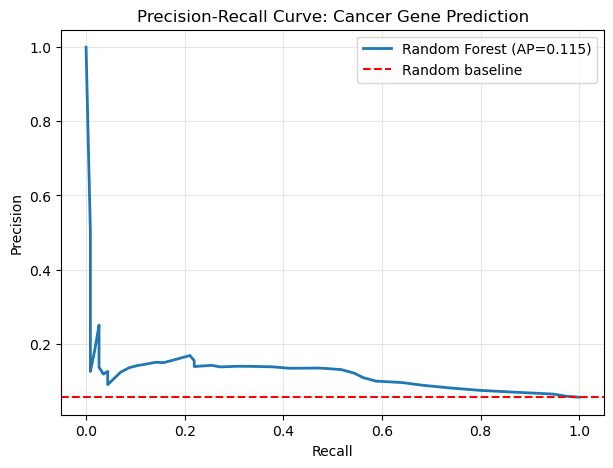

Classification Report:


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd

# Prepare features and target
X = merged.drop('NCG_Known_Cancer_Gene', axis=1)
y = merged['NCG_Known_Cancer_Gene']

# Encode target if it's not boolean
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split (80-20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Train a classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict probabilities for the positive class
y_prob = clf.predict_proba(X_test)[:, 1]

# Precision-recall curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f'Random Forest (AP={ap_score:.3f})', linewidth=2)
plt.axhline(y=sum(y_test)/len(y_test), color='red', linestyle='--', label='Random baseline')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Cancer Gene Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print classification report
y_pred = clf.predict(X_test)
print("Classification Report:")
